In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("../dataset/Churn_Modelling.csv")

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

In [ ]:
df.shape

(10000, 11)

In [ ]:
df.dtypes

,0
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64
IsActiveMember,int64
EstimatedSalary,float64


**EDA - Exploratory data Analysis**

Statistical Summary

In [ ]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Checking for missing values

In [ ]:
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


Checking the distribution of the target variable

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


Univariate Analysis

1. Age distribution

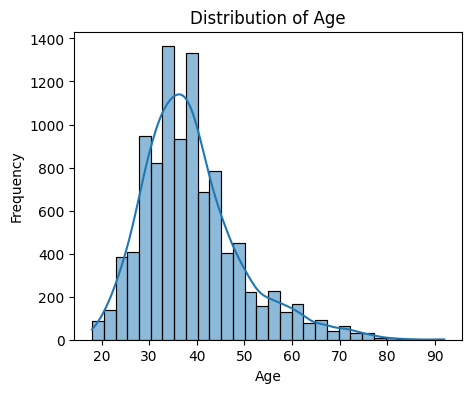

In [ ]:
plt.figure(figsize=(5,4))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

2. Balance distribution

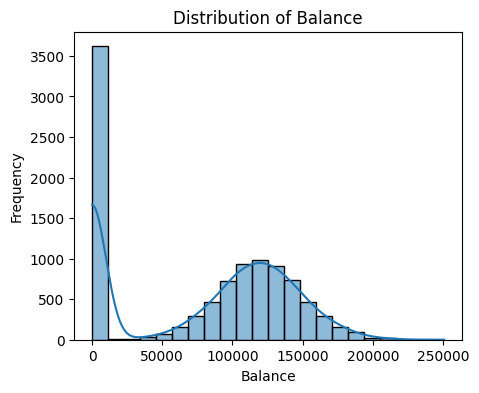

In [ ]:
plt.figure(figsize=(5,4))

sns.histplot(df["Balance"], kde=True)

plt.title("Distribution of Balance")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

3. Credit Score Distribution

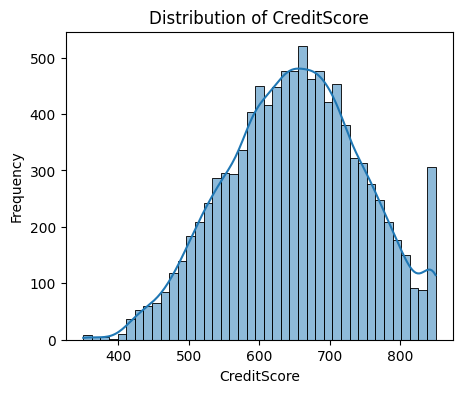

In [ ]:
plt.figure(figsize=(5,4))

sns.histplot(df["CreditScore"], kde=True)

plt.title("Distribution of CreditScore")
plt.xlabel("CreditScore")
plt.ylabel("Frequency")

plt.show()

ANalysis of categorical features

1. Geography distribution

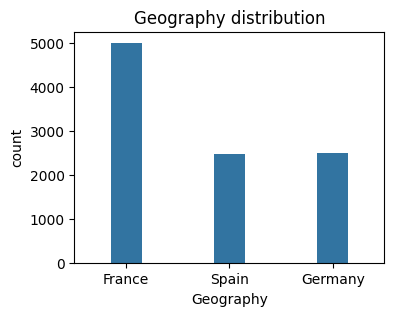

In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(x='Geography', data=df, width=0.3)

plt.title("Geography distribution")
plt.xlabel("Geography")
plt.ylabel("count")

plt.show()


2. Gender Distribution

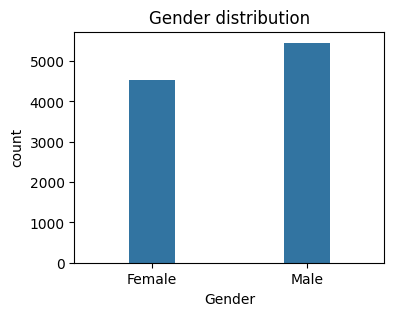

In [ ]:
plt.figure(figsize=(4,3))
sns.countplot(x='Gender', data=df, width=0.3)

plt.title("Gender distribution")
plt.xlabel("Gender")
plt.ylabel("count")

plt.show()


Bivariate Analysis

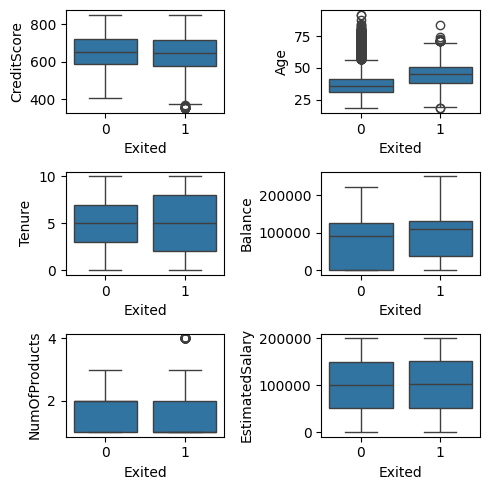

In [ ]:
fig, axarr =plt.subplots(3,2, figsize=(5,5))

sns.boxplot(x='Exited', y= 'CreditScore', data=df , ax=axarr[0][0])
sns.boxplot(x='Exited', y= 'Age', data=df , ax=axarr[0][1])

sns.boxplot(x='Exited', y= 'Tenure', data=df , ax=axarr[1][0])
sns.boxplot(x='Exited', y= 'Balance', data=df , ax=axarr[1][1])

sns.boxplot(x='Exited', y= 'NumOfProducts', data=df , ax=axarr[2][0])
sns.boxplot(x='Exited', y= 'EstimatedSalary', data=df , ax=axarr[2][1])

plt.tight_layout()
plt.show()


Correlation Analysis

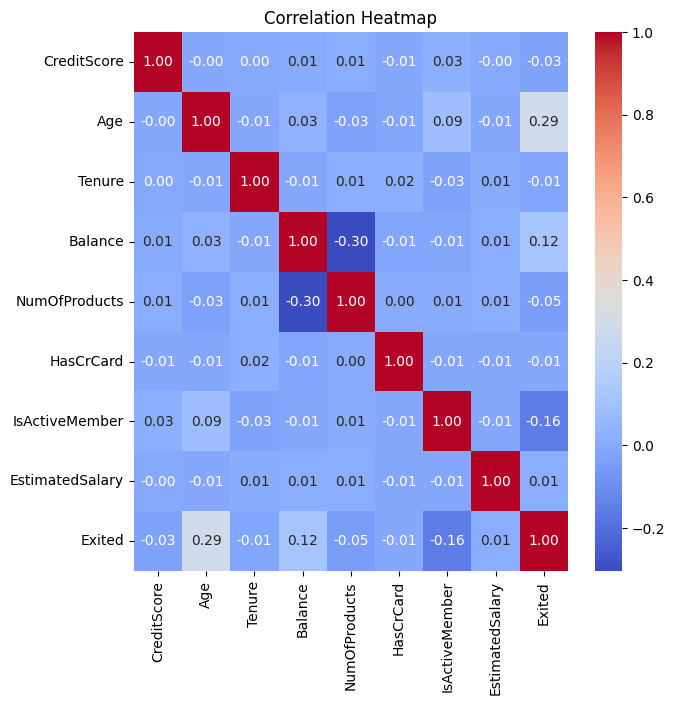

In [ ]:
plt.figure(figsize=(7,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

Feature Engineering

1. Balance to salary ratio

In [ ]:
df["balance_to_salary"]=df["Balance"]/df["EstimatedSalary"]

2. Tenure by age

In [ ]:
df["tenure_by_age"]=df["Tenure"]/df["Age"]

In [ ]:
df.shape

(10000, 13)

Feature Encoding

1. Label encoding - Gender

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()

In [ ]:
df["Gender"]=le.fit_transform(df["Gender"])

2. One GHot encoding - Geography

In [ ]:
df=pd.get_dummies(df, columns=["Geography"], drop_first=True)

In [ ]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_to_salary,tenure_by_age,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,0.000000,0.047619,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.744677,0.024390,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.401375,0.190476,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,0.000000,0.025641,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,1.587055,0.046512,False,True


**Defining Features anf the Target Variable **

In [ ]:
X= df.drop("Exited", axis=1)
y=df["Exited"]

**Splitting the dataset**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(8000, 13)

In [ ]:
y_test.shape

(2000,)

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc=StandardScaler()

In [ ]:
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

**Model Training**

1. Logistic Regression
2. KNN Classifier
3. Naive Bayes

4. Random Forest
5. XGB Classifier
6. ANN - Artificial Neural Network

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model=LogisticRegression()

In [ ]:
lr_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred_lr = lr_model.predict(X_test)

In [ ]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

In [ ]:
print("Accuracy: ", lr_accuracy)
print("Precision: ", lr_precision)
print("recall: ", lr_recall)
print("f1 Score: ", lr_f1)

Accuracy:  0.8125
Precision:  0.56
recall:  0.21374045801526717
f1 Score:  0.30939226519337015


In [ ]:
from sklearn.metrics import confusion_matrix

Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

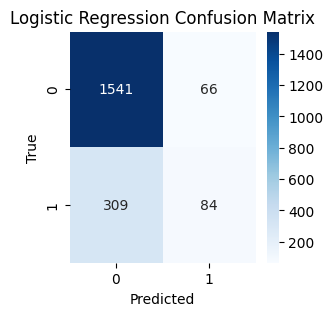

In [ ]:
cm=confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(3,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")

In [ ]:
cm

array([[1541,   66],
       [ 309,   84]])

In [ ]:
model_results=[]

model_results.append({"Model":"Logistic Regression",
                       "Accuracy":lr_accuracy,
                       "Precision":lr_precision,
                       "Recall":lr_recall,
                       "F1 Score":lr_f1})

2. KNN - Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn_model= KNeighborsClassifier()

In [ ]:
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_predict_knn= knn_model.predict(X_test)

In [ ]:
knn_accuracy = accuracy_score(y_test, y_predict_knn)
knn_precision = precision_score(y_test, y_predict_knn)
knn_recall = recall_score(y_test, y_predict_knn)
knn_f1 = f1_score(y_test, y_predict_knn)

In [ ]:
print("Accuracy: ", knn_accuracy)
print("Precision: ", knn_precision)
print("recall: ", knn_recall)
print("f1 Score: ", knn_f1)

Accuracy:  0.831
Precision:  0.6170212765957447
recall:  0.36895674300254455
f1 Score:  0.46178343949044587


Text(0.5, 1.0, 'KNN Classifier Confusion Matrix')

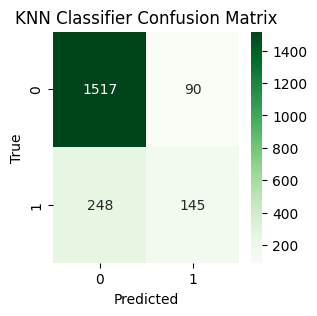

In [ ]:
cm=confusion_matrix(y_test, y_predict_knn)

plt.figure(figsize=(3,3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("KNN Classifier Confusion Matrix")

In [ ]:
model_results.append({"Model":"KNN Classifier",
                       "Accuracy":knn_accuracy,
                       "Precision":knn_precision,
                       "Recall":knn_recall,
                       "F1 Score":knn_f1})

Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb_model=GaussianNB()

In [ ]:
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_predict_nb= nb_model.predict(X_test)

In [ ]:
nb_accuracy=accuracy_score(y_test, y_predict_nb)
nb_precision= precision_score(y_test, y_predict_nb)
nb_recall = recall_score(y_test, y_predict_nb)
nb_f1 = f1_score(y_test, y_predict_nb)

print("accuracy:",nb_accuracy)
print("precision:",nb_precision)
print("recall:",nb_recall)
print("F1 score:",nb_f1)


accuracy: 0.8275
precision: 0.6967213114754098
recall: 0.21628498727735368
F1 score: 0.3300970873786408


In [ ]:
cm_nb= confusion_matrix(y_test, y_predict_nb)

In [ ]:
cm_nb

array([[1570,   37],
       [ 308,   85]])

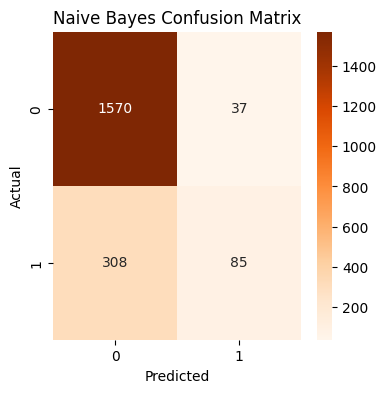

In [ ]:
plt.figure(figsize=(4,4))

sns.heatmap(cm_nb, annot=True, cmap='Oranges', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [ ]:
model_results.append({"Model":"Naive Bayes",
                       "Accuracy":nb_accuracy,
                       "Precision":nb_precision,
                       "Recall":nb_recall,
                       "F1 Score":nb_f1})

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model=RandomForestClassifier()

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_predict_rf= rf_model.predict(X_test)

In [ ]:
rf_accuracy=accuracy_score(y_test, y_predict_rf)
rf_precision= precision_score(y_test, y_predict_rf)
rf_recall = recall_score(y_test, y_predict_rf)
rf_f1 = f1_score(y_test, y_predict_rf)

print("accuracy:",rf_accuracy)
print("precision:",rf_precision)
print("recall:",rf_recall)
print("F1 score:",rf_f1)


accuracy: 0.869
precision: 0.7717842323651453
recall: 0.4732824427480916
F1 score: 0.5867507886435331


In [ ]:
model_results.append({"Model":"Random Forest",
                       "Accuracy":rf_accuracy,
                       "Precision":rf_precision,
                       "Recall":rf_recall,
                       "F1 Score":rf_f1})

**XG Boost**

In [ ]:
from xgboost import XGBClassifier
model_xgb= XGBClassifier()

In [ ]:
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_predict_xgb= model_xgb.predict(X_test)

In [ ]:
xgb_accuracy=accuracy_score(y_test, y_predict_xgb)
xgb_precision= precision_score(y_test, y_predict_xgb)
xgb_recall = recall_score(y_test, y_predict_xgb)
xgb_f1 = f1_score(y_test, y_predict_xgb)

print("accuracy:",xgb_accuracy)
print("precision:",xgb_precision)
print("recall:",xgb_recall)
print("F1 score:",xgb_f1)


accuracy: 0.8535
precision: 0.6798561151079137
recall: 0.48091603053435117
F1 score: 0.563338301043219


In [ ]:
model_results.append({"Model":"XG Boost Classifier",
                       "Accuracy":xgb_accuracy,
                       "Precision":xgb_precision,
                       "Recall":xgb_recall,
                       "F1 Score":xgb_f1})

**ANN- Artificial Neural network**

In [ ]:
import tensorflow as tf
from tensorflow import keras

In [ ]:
model= keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(12, activation='relu'),
    keras.layers.Dense(6, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
#Complie the model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model.fit(X_train, y_train,
                  epochs=100,
                  batch_size=32,
                  validation_split=0.2
                  )

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6773 - loss: 0.6137 - val_accuracy: 0.8019 - val_loss: 0.4982
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7983 - loss: 0.4811 - val_accuracy: 0.8131 - val_loss: 0.4392
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8042 - loss: 0.4480 - val_accuracy: 0.8213 - val_loss: 0.4244
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8108 - loss: 0.4359 - val_accuracy: 0.8231 - val_loss: 0.4197
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8147 - loss: 0.4276 - val_accuracy: 0.8263 - val_loss: 0.4148
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8203 - loss: 0.4199 - val_accuracy: 0.8338 - val_loss: 0.4089
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8253 - loss: 0.4104 - val_accuracy: 0.8369 - val_loss: 0.4000
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8336 - loss: 0.3974 - val_accu

In [ ]:
y_pred_ann=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
y_pred_ann=(y_pred_ann>0.5)

In [ ]:
ann_accuracy=accuracy_score(y_test, y_pred_ann)
ann_precision= precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)

print("accuracy:",ann_accuracy)
print("precision:",ann_precision)
print("recall:",ann_recall)
print("F1 score:",ann_f1)


accuracy: 0.859
precision: 0.7047970479704797
recall: 0.4860050890585242
F1 score: 0.5753012048192772


In [ ]:
model_results.append({"Model":"ANN Model",
                       "Accuracy":ann_accuracy,
                       "Precision":ann_precision,
                       "Recall":ann_recall,
                       "F1 Score":ann_f1})

**Conclusion**

In [ ]:
result_df= pd.DataFrame(model_results)

In [ ]:
result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8125,0.560000,0.213740,0.309392
1,KNN Classifier,0.8310,0.617021,0.368957,0.461783
2,Naive Bayes,0.8275,0.696721,0.216285,0.330097
3,Random Forest,0.8690,0.771784,0.473282,0.586751
4,XG Boost Classifier,0.8535,0.679856,0.480916,0.563338
5,ANN Model,0.8590,0.704797,0.486005,0.575301
